# Análisis Exploratorio de Datos (EDA)
## Proyecto Integrador M5  Modelo de Riesgo Crediticio

**Autor:** Simón Bedoya Montiel
**Carrera:** Data Science - Soy Henry

Este notebook contiene el análisis exploratorio de la base de datos de créditos. El objetivo es comprender la estructura de los datos, evaluar su calidad, identificar patrones relacionados con el pago a tiempo, y definir las reglas de validación y transformaciones para las etapas siguientes del pipeline

In [1]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de visualizacion
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Se importa la funcion de carga desde el modulo cargar_datos
import sys
sys.path.append('.')
from cargar_datos import cargar_datos

# Se cargan los datos crudos
df = cargar_datos("../Base_de_datos.xlsx")
df.head()

Datos cargados correctamente: 10763 filas y 23 columnas.


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## Exploración Inicial de los Datos

Se revisa la estructura general del dataset: dimensiones, tipos de datos, y una primera caracterización de las variables.

In [3]:
# Dimensiones del dataset
print(f"El dataset tiene {df.shape[0]} registros y {df.shape[1]} variables.\n")

# Tipos de datos de cada variable
print("Tipos de datos por columna:")
df.info()

El dataset tiene 10763 registros y 23 variables.

Tipos de datos por columna:
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacre

In [4]:
# Se separan las variables segun su naturaleza para analizarlas mejor
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object', 'string']).columns.tolist()
variables_fecha = df.select_dtypes(include=['datetime64']).columns.tolist()

print(f"Variables numéricas ({len(variables_numericas)}):")
print(variables_numericas)
print(f"\nVariables categóricas ({len(variables_categoricas)}):")
print(variables_categoricas)
print(f"\nVariables de fecha ({len(variables_fecha)}):")
print(variables_fecha)

Variables numéricas (20):
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']

Variables categóricas (2):
['tipo_laboral', 'tendencia_ingresos']

Variables de fecha (1):
['fecha_prestamo']


**Observación:** Varias variables numéricas son en realidad categóricas codificadas, como tipo_credito, que representa códigos de tipo de crédito y no cantidades. Esto se corregirá en la etapa de ajuste de tipos. La variable objetivo es Pago_atiempo.

## Evaluación de la Calidad de los Datos

Se analizan los valores nulos, los valores atípicos o inconsistentes, y se identifican las columnas que requieren corrección de tipo o limpieza.

In [5]:
# Conteo y porcentaje de valores nulos por columna
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje': porcentaje_nulos
})

# Se muestran solo las columnas que tienen nulos, ordenadas
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Columnas con valores nulos:")
print(tabla_nulos)

Columnas con valores nulos:
                               Nulos  Porcentaje
tendencia_ingresos              2932       27.24
promedio_ingresos_datacredito   2930       27.22
saldo_mora_codeudor              590        5.48
saldo_principal                  405        3.76
saldo_mora                       156        1.45
saldo_total                      156        1.45
puntaje_datacredito                6        0.06


In [6]:
# La variable tendencia_ingresos deberia tener solo categorias de texto,
# pero contiene valores numericos mezclados. Se revisan sus valores unicos.
print("Valores únicos en tendencia_ingresos:")
print(df['tendencia_ingresos'].value_counts().head(10))
print(f"\nTotal de valores distintos: {df['tendencia_ingresos'].nunique()}")

Valores únicos en tendencia_ingresos:
tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
Name: count, dtype: int64

Total de valores distintos: 46


**Hallazgo importante:** La variable tendencia_ingresos debería contener únicamente tres categorías (Creciente, Decreciente, Estable), pero presenta valores numéricos mezclados que corresponden a errores de captura. Estos valores inválidos se tratarán como nulos en la etapa de limpieza. Los nulos más significativos están en tendencia_ingresos y promedio_ingresos_datacredito, con cerca del 27% de datos faltantes.

In [7]:
# Se revisan valores minimos y maximos de variables clave
# para detectar datos imposibles o inconsistentes.
columnas_revisar = ['edad_cliente', 'puntaje', 'puntaje_datacredito',
                    'salario_cliente', 'tipo_credito', 'plazo_meses']

for col in columnas_revisar:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

edad_cliente: min = 19, max = 123
puntaje: min = -38.00999, max = 95.227787
puntaje_datacredito: min = -7.0, max = 999.0
salario_cliente: min = 0, max = 22000000000
tipo_credito: min = 4, max = 68
plazo_meses: min = 2, max = 90


**Reglas de validación identificadas:** A partir de los valores mínimos y máximos se detectan datos fuera de rango que servirán para construir las reglas de validación del pipeline:

- edad_cliente: debe estar en un rango realista (por ejemplo, 18 a 100 años). El máximo de 123 es inválido.
- puntaje: parece medirse en una escala de 0 a 100. Los valores negativos son inválidos.
- puntaje_datacredito: escala de 0 a 999. El valor negativo es inválido.
- salario_cliente: presenta valores en cero y magnitudes irreales que deben acotarse.
- tipo_credito: los valores frecuentes son pocos; los valores muy altos podrían ser errores de captura por revisar.

Estas reglas se aplicarán en la etapa de validación y limpieza de datos.

## Preparación de una Vista para Exploración

Para poder visualizar correctamente las variables, se crea una copia temporal del dataset con ajustes mínimos que solo aplican a esta etapa de exploración. El dataset original permanece sin modificar. La limpieza y transformación formal se implementará en la etapa de ingeniería de características (ft_engineering.py).

In [8]:
# Se crea una copia temporal solo para la exploracion visual
df_exp = df.copy()

# Ajuste 1: en tendencia_ingresos se conservan solo las categorias validas.
# Los valores numericos invalidos se marcan como nulos (solo para explorar).
categorias_validas = ['Creciente', 'Decreciente', 'Estable']
df_exp['tendencia_ingresos'] = df_exp['tendencia_ingresos'].where(
    df_exp['tendencia_ingresos'].isin(categorias_validas), other=np.nan)

# Ajuste 2: se convierten a categoricas las variables que son codigos, no cantidades
df_exp['tipo_credito'] = df_exp['tipo_credito'].astype('category')
df_exp['Pago_atiempo'] = df_exp['Pago_atiempo'].astype('category')

# Verificacion rapida
print("tendencia_ingresos ahora tiene estas categorías:")
print(df_exp['tendencia_ingresos'].value_counts(dropna=False))

tendencia_ingresos ahora tiene estas categorías:
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


**Nota:** Estos ajustes son exclusivos de la etapa de exploración y no modifican el dataset original. En tendencia_ingresos, los valores numéricos inválidos se agrupan ahora como nulos, quedando únicamente las tres categorías legítimas. Las variables tipo_credito y Pago_atiempo se tratan como categóricas por representar códigos y no magnitudes.

## Análisis Univariable

Se analiza cada variable de forma individual. Para las variables numéricas se estudian su distribución (histograma), sus valores atípicos (boxplot) y sus medidas estadísticas. Para las categóricas se estudia la frecuencia de cada categoría.

In [9]:
# Descripcion estadistica de las variables numericas
# Incluye tendencia central, dispersion y forma de la distribucion
df_exp.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha_prestamo,10763,2025-04-16 23:06:02.111121,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
salario_cliente,10763.0,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.603482
total_otros_prestamos,10763.0,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.941069
cuota_pactada,10763.0,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441
puntaje_datacredito,10757.0,780.790834,-7.0,757.0,791.0,825.0,999.0,104.878031
cant_creditosvigentes,10763.0,5.726749,0.0,3.0,5.0,8.0,62.0,3.977162


**Hallazgos adicionales de la descripción estadística:**

- puntaje presenta un comportamiento casi constante: sus cuartiles y su máximo coinciden en el mismo valor (95.23), lo que indica muy baja variabilidad. Esta variable podría aportar poca información al modelo y se evaluará su utilidad.
- Variables como saldo_mora y saldo_mora_codeudor tienen el 75% de sus valores en cero, reflejando que la mayoría de clientes no presenta mora. Son variables muy concentradas con pocos valores altos.
- salario_cliente confirma valores atípicos extremos: su desviación estándar supera ampliamente a su media, distorsionada por los máximos irreales.

In [10]:
# Skewness (asimetria) y kurtosis (forma de la distribucion)
# para entender como se distribuyen las variables numericas
numericas = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
            'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'saldo_total']

for col in numericas:
    asimetria = df_exp[col].skew()
    curtosis = df_exp[col].kurt()
    print(f"{col}: asimetría = {asimetria:.2f}, curtosis = {curtosis:.2f}")

capital_prestado: asimetría = 3.72, curtosis = 35.32
plazo_meses: asimetría = 2.46, curtosis = 7.78
edad_cliente: asimetría = 1.93, curtosis = 7.87
salario_cliente: asimetría = 43.78, curtosis = 2211.23
cuota_pactada: asimetría = 3.79, curtosis = 26.65
puntaje: asimetría = -4.87, curtosis = 24.08
puntaje_datacredito: asimetría = -5.64, curtosis = 39.44
saldo_total: asimetría = 20.20, curtosis = 789.17


**Interpretación de las distribuciones:** La mayoría de las variables numéricas presentan fuerte asimetría y curtosis elevada, lo que indica distribuciones alejadas de la normalidad y con presencia de valores atípicos:

- salario_cliente y saldo_total muestran asimetría y curtosis extremas, confirmando la presencia de valores atípicos severos que distorsionan la escala.
- capital_prestado y cuota_pactada tienen sesgo positivo, coherente con montos de crédito donde predominan valores bajos y existen pocos muy altos.
- puntaje y puntaje_datacredito presentan asimetría negativa, indicando que la mayoría de los clientes concentra puntajes altos.

Estas características sugieren que en la etapa de ingeniería de características podrían aplicarse transformaciones (por ejemplo, logarítmicas) y tratamiento de outliers para las variables más sesgadas.

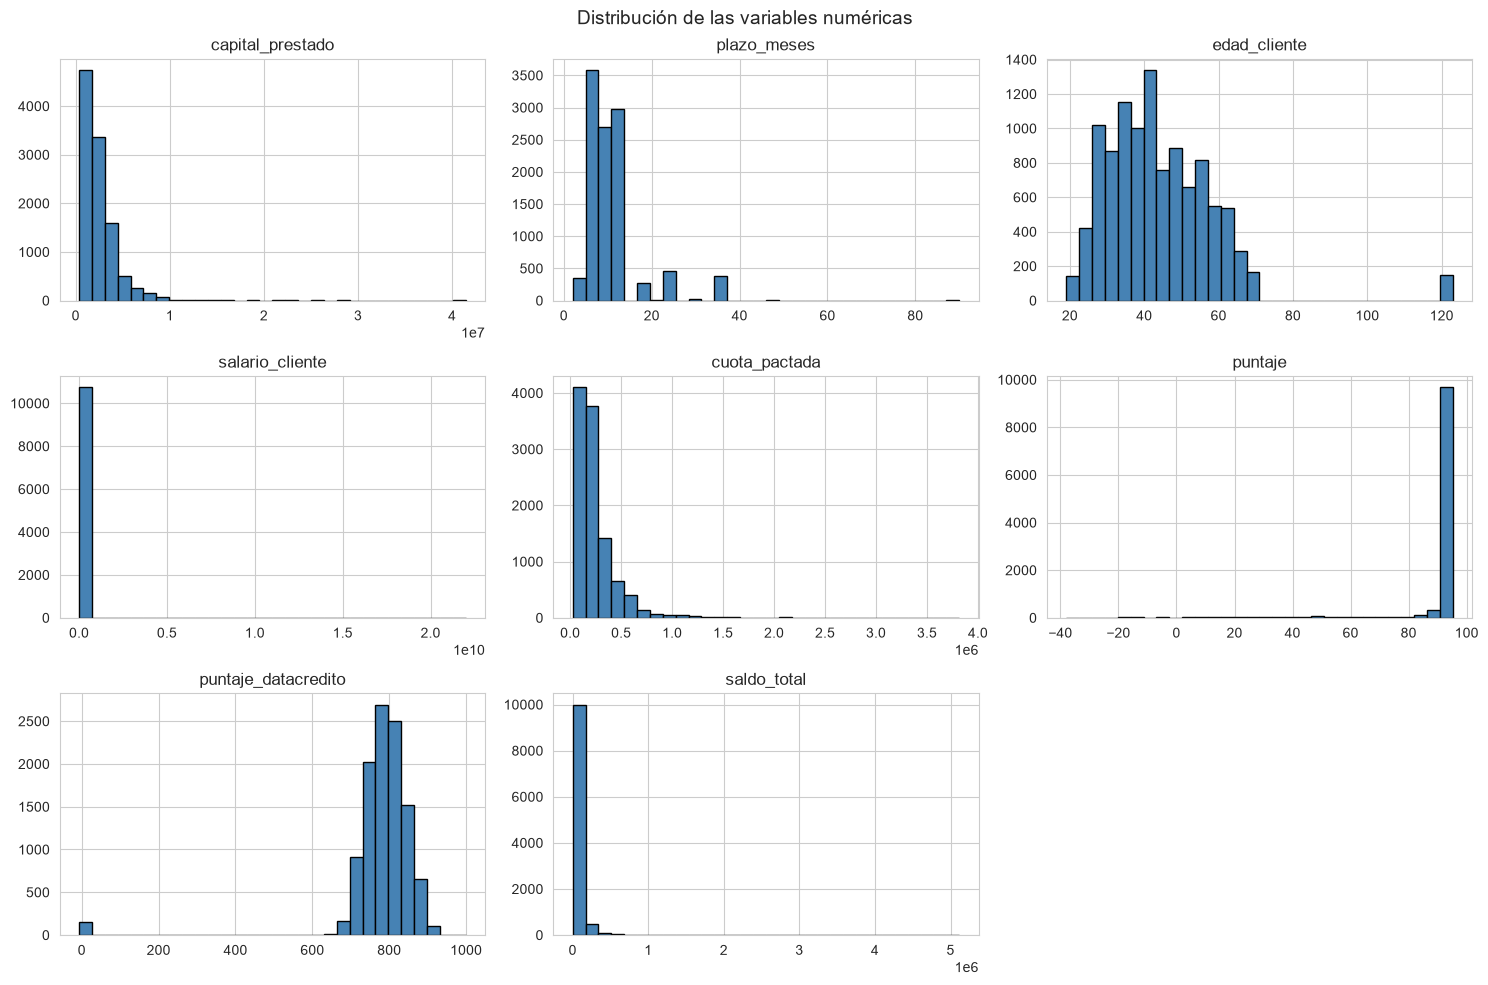

In [11]:
# Histogramas para ver la distribucion de las variables numericas
df_exp[numericas].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de las variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación de los histogramas:**

Las distribuciones confirman los valores de asimetría y curtosis calculados antes. Los hallazgos principales son:

- **Variables monetarias sesgadas** (capital_prestado, cuota_pactada, salario_cliente, saldo_total): presentan sesgo positivo extremo, con la mayoría de los valores concentrados cerca de cero y colas largas hacia la derecha. salario_cliente es la más problemática: una sola barra domina toda la escala por la presencia de valores extremos irreales. Estas variables son candidatas a transformación logarítmica y tratamiento de outliers.

- **edad_cliente**: distribución acampanada con la mayoría de clientes entre 28 y 55 años, más una barra completamente aislada cerca de los 120 años, separada del resto por un vacío. Se confirma como error de captura.

- **puntaje_datacredito**: su cuerpo principal es una campana bien formada entre 700 y 850, pero presenta una barra aislada en cero, separada por un gran vacío. Estos ceros corresponden a datos no consultados y deben tratarse como valores faltantes, no como puntajes reales.

- **puntaje**: concentra más del 90% de los casos en un valor cercano a 95, con valores negativos dispersos que funcionan como códigos centinela (sin evaluación), no como puntajes reales. Su baja variabilidad limita su aporte al modelo.

- **plazo_meses**: muestra grupos de barras separados por huecos, lo que sugiere que los plazos están estandarizados en valores típicos de producto (6, 12, 24 meses) en lugar de ser continuos.

### Análisis de valores atípicos (boxplots)

Los diagramas de caja permiten visualizar la mediana, los cuartiles y los valores atípicos de cada variable numérica. Son especialmente útiles para dimensionar los outliers detectados en el análisis anterior.

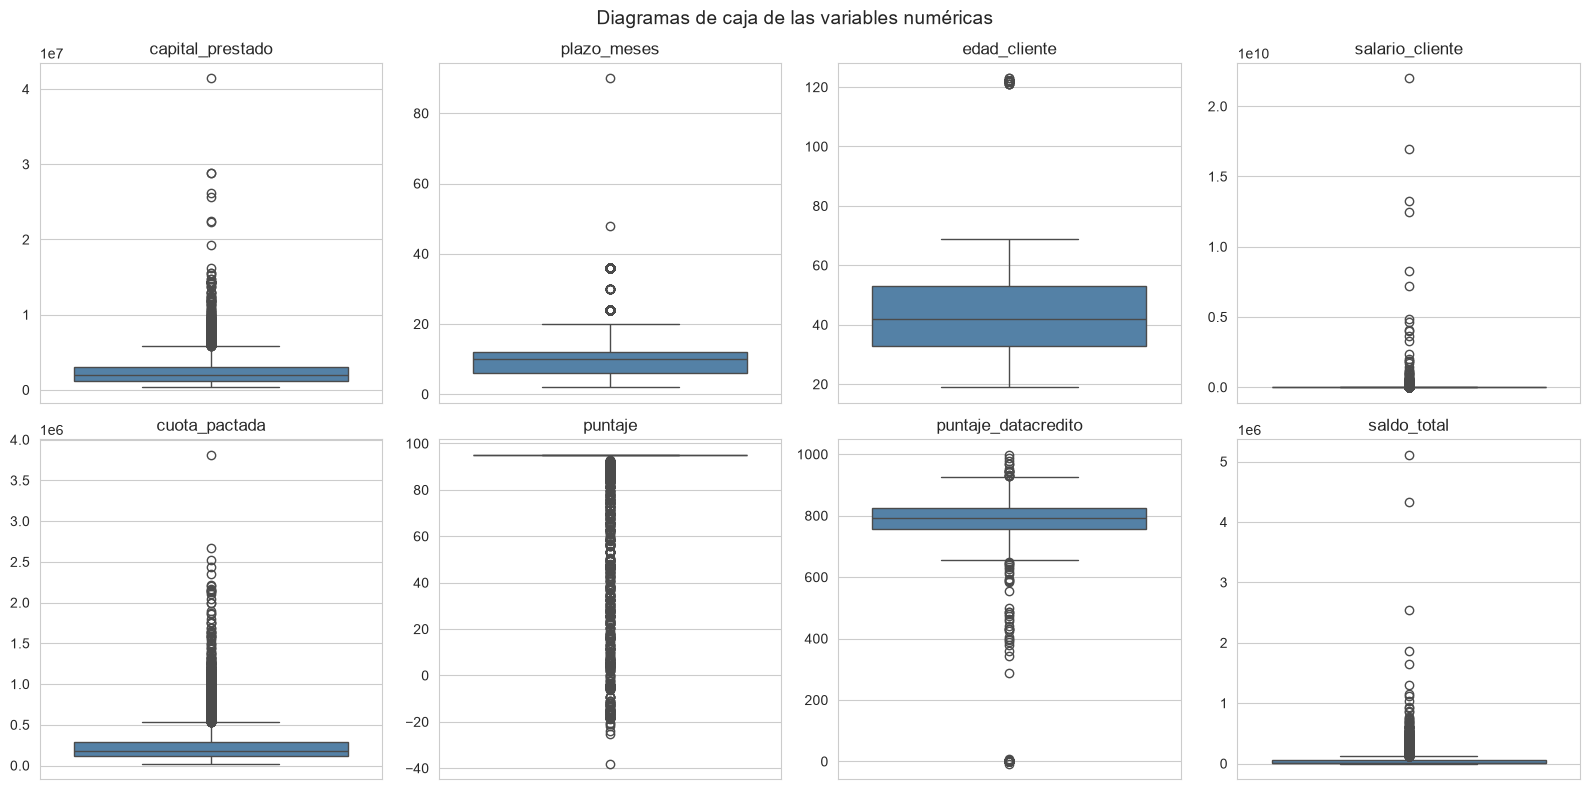

In [12]:
# Boxplots de las variables numericas para visualizar outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(y=df_exp[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('Diagramas de caja de las variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación de los diagramas de caja:**

Los boxplots confirman y dimensionan los valores atípicos detectados. Se identifican tres patrones:

- **Variables monetarias con outliers masivos** (capital_prestado, cuota_pactada, salario_cliente, saldo_total): presentan cajas muy pequeñas respecto a la escala, con una nube densa y continua de valores atípicos hacia arriba. Los casos más extremos están enormemente alejados del resto: salario_cliente alcanza valores cercanos a 22.000 millones y capital_prestado cerca de 41 millones. capital_prestado y cuota_pactada muestran un patrón casi idéntico, coherente con su relación directa (la cuota depende del capital).

- **edad_cliente**: es la única variable con una caja proporcional y bien formada (entre 33 y 53 años, mediana en 42). Su único problema es un valor aislado cerca de los 121 años, separado del resto por un vacío, que corresponde a un dato inválido y no a un outlier genuino.

- **Variables de puntaje con valores especiales**:
  - puntaje no presenta la forma clásica de caja y bigotes: la mayoría de los valores se concentran cerca de 95 y una minoría se dispersa hacia abajo hasta valores negativos (cerca de -38), que actúan como códigos especiales, no como puntajes reales.
  - puntaje_datacredito tiene una caja bien definida (760 a 830), pero sus valores atípicos se dividen en dos poblaciones: valores bajos genuinos (entre 300 y 650, posibles clientes de score real bajo) y un grupo compacto en cero, separado del resto, que corresponde a datos no consultados y debe tratarse como faltante.

**Conclusión del análisis univariable:** El dataset requiere un tratamiento cuidadoso de outliers y valores especiales antes del modelado. Las variables monetarias son candidatas a transformación logarítmica o winsorización. Los valores centinela (negativos en puntaje, ceros en puntaje_datacredito, edad de 121 años) deben convertirse a nulos o corregirse según las reglas de validación definidas.

### Análisis de variables categóricas

Se analiza la frecuencia de cada categoría en las variables cualitativas del dataset.

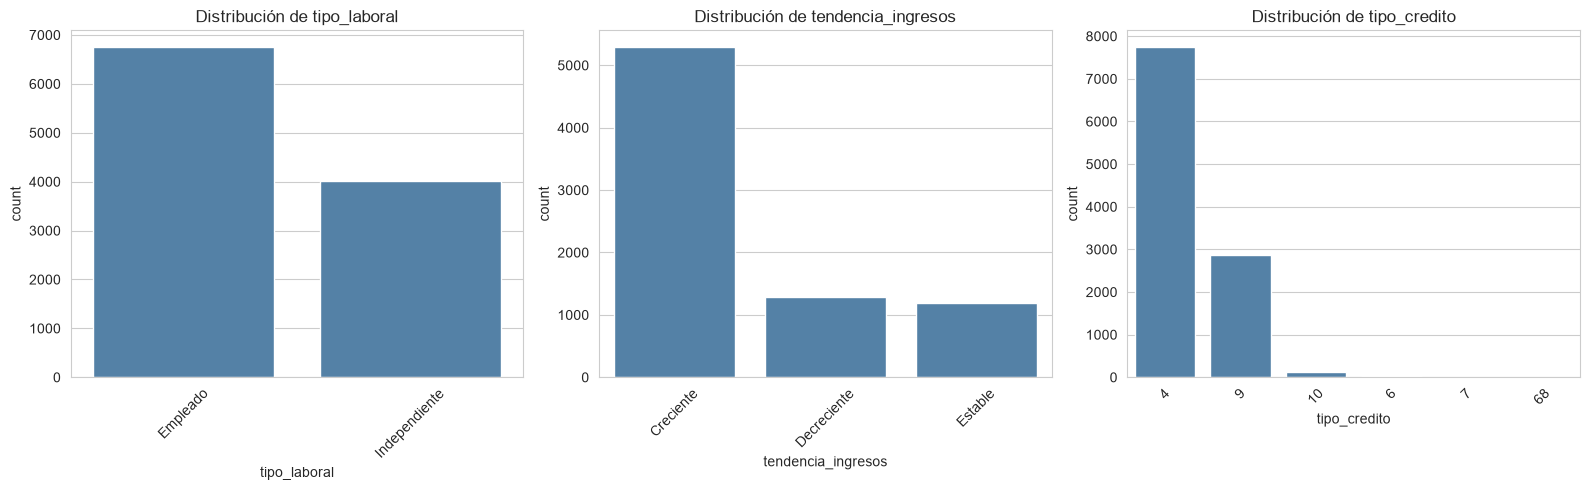

In [13]:
# Variables categoricas a analizar
categoricas = ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categoricas):
    orden = df_exp[col].value_counts().index
    sns.countplot(data=df_exp, x=col, order=orden, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretación de las variables categóricas:**

- **tipo_laboral**: distribución razonablemente equilibrada entre Empleado (6.754 casos, 63%) e Independiente (4.009 casos, 37%). Ambas categorías tienen representación suficiente para el análisis.

- **tendencia_ingresos**: predomina la categoría Creciente (5.294 casos), seguida de Decreciente (1.291) y Estable (1.188). Se observa un desbalance hacia clientes con ingresos crecientes. Cerca del 27% de los registros no tiene valor válido en esta variable.

- **tipo_credito**: fuertemente concentrada en dos categorías, el tipo 4 (72%) y el tipo 9 (27%), que juntas representan el 99% de los datos. Las categorías restantes (10, 6, 7) son marginales, y el valor 68, con un único registro, corresponde muy probablemente a un error de captura. Se evaluará agrupar las categorías minoritarias o tratar los valores anómalos en la etapa de limpieza.

## Análisis Bivariable

Se estudia la relación de cada variable con la variable objetivo Pago_atiempo. El objetivo es identificar qué características diferencian a los clientes que pagan a tiempo de los que no, información clave para el modelado posterior.

### Variables numéricas frente a la variable objetivo

In [15]:
# Comparacion de la media de cada variable numerica segun Pago_atiempo
# Permite ver que variables difieren entre quienes pagan y quienes no
comparacion = df_exp.groupby('Pago_atiempo', observed=True)[numericas].mean().T
comparacion.columns = ['No pagó (0)', 'Pagó a tiempo (1)']
comparacion['Diferencia relativa %'] = (
    (comparacion['Pagó a tiempo (1)'] - comparacion['No pagó (0)'])
    / comparacion['No pagó (0)'] * 100
).round(1)
print(comparacion)

                      No pagó (0)  Pagó a tiempo (1)  Diferencia relativa %
capital_prestado     2.781774e+06       2.416996e+06                  -13.1
plazo_meses          1.245010e+01       1.048215e+01                  -15.8
edad_cliente         4.177299e+01       4.405706e+01                    5.5
salario_cliente      2.355514e+07       1.690049e+07                  -28.3
cuota_pactada        2.547557e+05       2.430622e+05                   -4.6
puntaje              2.309122e+01       9.456335e+01                  309.5
puntaje_datacredito  7.488804e+02       7.823790e+02                    4.5
saldo_total          3.907492e+04       4.627690e+04                   18.4


**Interpretación de las variables numéricas frente a la objetivo:**

La comparación de medias entre quienes pagan y quienes no pagan revela diferencias muy relevantes:

- **puntaje** es la variable más discriminante con diferencia: quienes no pagan tienen un puntaje promedio de 23, frente a 94,5 de quienes sí pagan (una diferencia superior al 300%). Esto matiza la observación del análisis univariable: aunque la mayoría de clientes se concentra en valores altos, los pocos con puntaje bajo corresponden precisamente a los que no pagan. La variable es altamente predictiva.

- **salario_cliente** muestra que quienes no pagan tienen mayor salario promedio, un resultado contraintuitivo que probablemente está distorsionado por los valores atípicos extremos detectados. Debe reinterpretarse tras la limpieza.

- **plazo_meses** y **capital_prestado**: quienes no pagan tienden a tener plazos más largos y montos más altos, coherente con un mayor riesgo asociado a créditos grandes y prolongados.

- **edad_cliente** y **puntaje_datacredito**: presentan diferencias menores, con quienes pagan siendo levemente mayores y con mejor score de DataCrédito.

La variable puntaje se perfila como el predictor más fuerte del comportamiento de pago.

In [16]:
# Tasa de pago segun cada variable categorica
for col in categoricas:
    print(f"\n--- {col} vs Pago_atiempo ---")
    tabla = pd.crosstab(df_exp[col], df_exp['Pago_atiempo'],
                        normalize='index') * 100
    tabla.columns = ['% No pagó', '% Pagó']
    print(tabla.round(1))


--- tipo_laboral vs Pago_atiempo ---
               % No pagó  % Pagó
tipo_laboral                    
Empleado             4.3    95.7
Independiente        5.5    94.5

--- tendencia_ingresos vs Pago_atiempo ---
                    % No pagó  % Pagó
tendencia_ingresos                   
Creciente                 3.9    96.1
Decreciente               6.3    93.7
Estable                   4.6    95.4

--- tipo_credito vs Pago_atiempo ---
              % No pagó  % Pagó
tipo_credito                   
4                   4.7    95.3
6                  42.9    57.1
7                   0.0   100.0
9                   4.7    95.3
10                  2.6    97.4
68                  0.0   100.0


**Interpretación de las variables categóricas frente a la objetivo:**

- **tipo_laboral**: los clientes independientes presentan una tasa de no pago ligeramente superior (5,5%) frente a los empleados (4,3%), coherente con la mayor estabilidad de ingresos de estos últimos.

- **tendencia_ingresos**: se observa un patrón claro y lógico. Los clientes con ingresos decrecientes tienen la mayor tasa de no pago (6,3%), frente a los de ingresos crecientes (3,9%). La tendencia de ingresos se relaciona de forma coherente con la capacidad de pago.

- **tipo_credito**: las categorías 4 y 9, que concentran el 99% de los datos, presentan tasas de no pago casi idénticas (4,7%). Las categorías minoritarias (6, 7, 68) muestran porcentajes extremos (42,9%, 0%, 0%), pero se basan en muy pocos registros (entre 1 y 21 casos), por lo que no son estadísticamente confiables y no deben interpretarse como patrones reales.

**Síntesis del análisis bivariable:** Las variables más relacionadas con el comportamiento de pago son puntaje (la más fuerte), la tendencia_ingresos, el plazo_meses y el tipo_laboral. Estas variables serán candidatas prioritarias para el modelado.

## Análisis Multivariable

Se estudian las relaciones entre las variables numéricas de forma conjunta, principalmente mediante la matriz de correlación, para identificar variables redundantes o fuertemente asociadas.

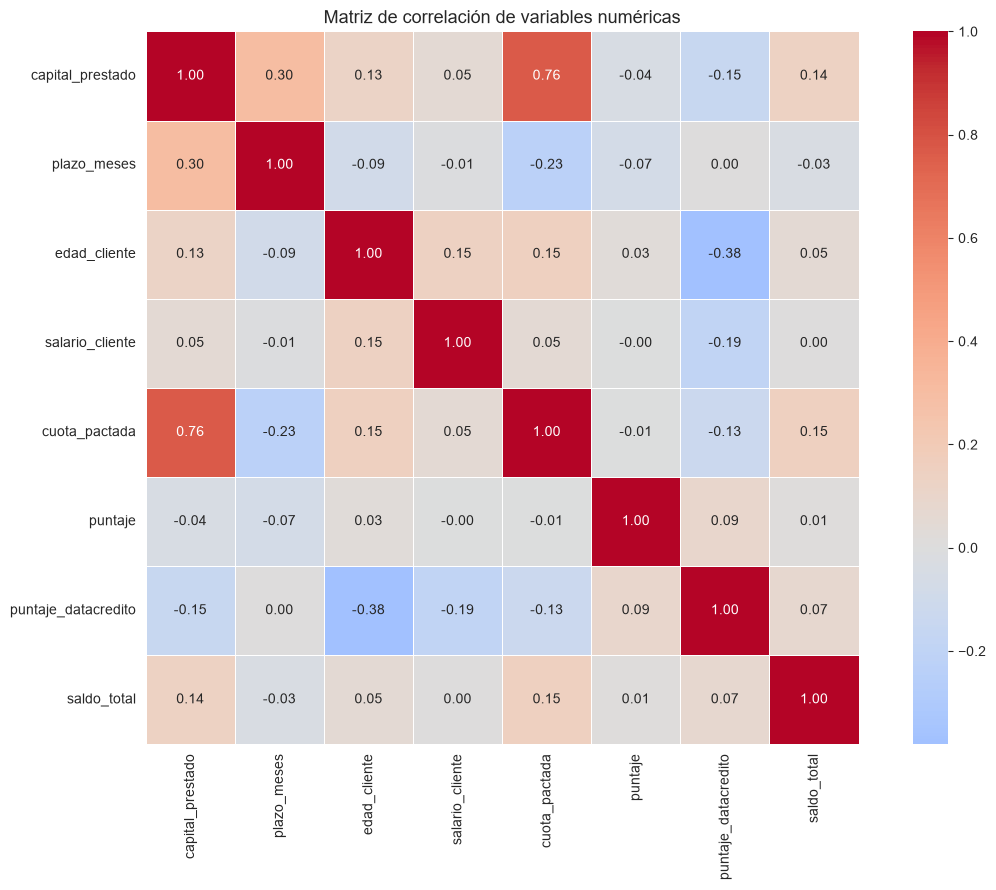

In [17]:
# Matriz de correlacion entre las variables numericas
plt.figure(figsize=(12, 9))
matriz_corr = df_exp[numericas].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de correlación de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación del análisis multivariable:**

La matriz de correlación revela una estructura de dependencias mayormente baja, con hallazgos puntuales relevantes:

- **Única correlación fuerte:** capital_prestado y cuota_pactada presentan una correlación de 0,76, la más alta del dataset. Es coherente, ya que la cuota se calcula a partir del capital. Esta redundancia debe atenderse en el modelado para evitar multicolinealidad, por ejemplo eliminando una de las dos o creando una variable derivada como la razón cuota sobre capital.

- **Correlación moderada:** edad_cliente y puntaje_datacredito se relacionan negativamente (-0,38): a mayor edad, menor score de DataCrédito en promedio.

- **Variables independientes:** puntaje muestra correlaciones cercanas a cero con todas las demás variables. Esto, combinado con su fuerte relación con la variable objetivo observada en el análisis bivariable, indica que aporta información única y valiosa que no está contenida en el resto de variables.

- **Ausencia de multicolinealidad generalizada:** salvo el par capital-cuota, las variables aportan información mayormente independiente, lo que es favorable para el modelado.

## Conclusiones del Análisis Exploratorio

Esta sección consolida los hallazgos del EDA y define las acciones para las etapas siguientes del pipeline: reglas de validación, transformaciones y variables derivadas.

### Reglas de validación de datos

A partir de los valores inconsistentes detectados, se proponen las siguientes reglas de validación:

- **edad_cliente**: debe estar entre 18 y 100 años. Valores fuera de este rango (como el registro de 121 años) se consideran inválidos.
- **puntaje**: debe estar entre 0 y 100. Los valores negativos corresponden a códigos especiales y se tratarán como nulos.
- **puntaje_datacredito**: debe estar entre 1 y 999. El valor cero corresponde a datos no consultados y se tratará como nulo.
- **salario_cliente**: debe ser mayor a cero y estar dentro de un rango razonable. Los valores extremos (superiores a miles de millones) se consideran errores de captura.
- **tendencia_ingresos**: solo se aceptan las categorías Creciente, Decreciente y Estable. Cualquier otro valor se trata como nulo.
- **tipo_credito**: se conservan las categorías con representación suficiente (4 y 9); las categorías con un único registro (como el código 68) se consideran errores.

### Transformaciones sugeridas

- Aplicar transformación logarítmica a las variables monetarias con sesgo extremo: capital_prestado, cuota_pactada, salario_cliente y saldo_total.
- Tratar los valores atípicos mediante winsorización o acotamiento por percentiles.
- Imputar los valores nulos según su naturaleza (por ejemplo, mediana para numéricas, categoría más frecuente o indicador de faltante para categóricas).

### Variables derivadas propuestas

- **Razón cuota sobre capital**: para resumir la relación entre cuota_pactada y capital_prestado y reducir la multicolinealidad.
- **Razón de endeudamiento**: relación entre total_otros_prestamos y salario_cliente, para medir la carga financiera del cliente.
- **Indicador de mora**: variable binaria que señale si el cliente tiene algún saldo en mora.
- **Antigüedad del préstamo**: derivada de fecha_prestamo, para capturar el tiempo transcurrido.

### Consideraciones para el modelado

- La variable objetivo Pago_atiempo está fuertemente desbalanceada (95% frente a 5%), por lo que se priorizarán métricas como recall y F1, y se aplicarán técnicas de manejo del desbalance.
- La variable puntaje se perfila como el predictor más fuerte, seguida de tendencia_ingresos, plazo_meses y tipo_laboral.